# Exercise 2 — 2D Grid Cell Model

Exercise 2 extends the 1D velocity integrator from Exercise 1 to a 2D neural sheet. Instead of a bump moving on a ring, the goal is to generate a 2D grid-like activity pattern, similar to the firing pattern of grid cells in the entorhinal cortex.

Each neuron now has a position $(x,y)$, and recurrent input is computed using a 2D Mexican-hat kernel:

$$
W(\vec{x}) =
A_{\mathrm{exc}} e^{-\|\vec{x}\|^2 / \sigma_{\mathrm{exc}}^2}
-
A_{\mathrm{inh}} e^{-\|\vec{x}\|^2 / \sigma_{\mathrm{inh}}^2}.
$$

This kernel represents local excitation and broader inhibition, which can produce stable periodic activity patterns.

To integrate 2D velocity, the model uses four populations: North, South, East, and West. Their inputs are modulated by the velocity vector $\vec{v}=(v_x,v_y)$. Horizontal velocity changes the balance between East and West populations, while vertical velocity changes the balance between North and South populations.

When $\vec{v}=(0,0)$, the grid pattern should stabilize. When velocity is applied, the entire grid pattern should translate in the corresponding direction. Thus, the network acts as a simplified 2D path integrator.

2.1:  4 distinct populations

In [1]:
import numpy as np
import matplotlib.pyplot as plt


def mexican_hat_2d(x, y, A_exc=1.0, sigma_exc=4.8, A_inh=1.0, sigma_inh=5.0):
    """
    Compute 2D Mexican-hat connectivity kernel.

    Parameters
    ----------
    x, y : array-like
        2D coordinate grids.
    A_exc, sigma_exc : float
        Amplitude and width of local excitation.
    A_inh, sigma_inh : float
        Amplitude and width of broader inhibition.

    Returns
    -------
    W : array-like
        2D interaction weight.
    """
    r2 = x**2 + y**2
    W = A_exc * np.exp(-r2 / sigma_exc**2) - A_inh * np.exp(-r2 / sigma_inh**2)
    return W

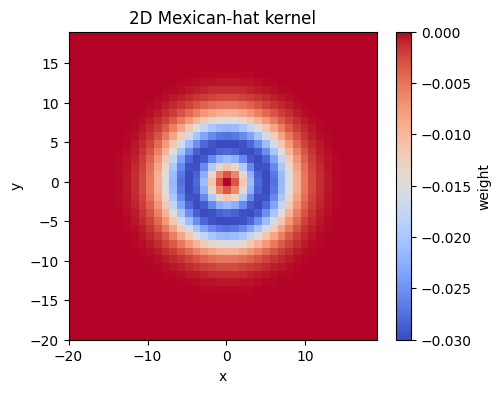

In [2]:
M = 40

x = np.arange(-M // 2, M // 2)
y = np.arange(-M // 2, M // 2)

X, Y = np.meshgrid(x, y, indexing="xy")

W_2d = mexican_hat_2d(
    X, Y,
    A_exc=1.0,
    sigma_exc=4.8,
    A_inh=1.0,
    sigma_inh=5.0,
)

plt.figure(figsize=(5, 4))
plt.imshow(
    W_2d,
    origin="lower",
    cmap="coolwarm",
    extent=[x.min(), x.max(), y.min(), y.max()]
)
plt.colorbar(label="weight")
plt.xlabel("x")
plt.ylabel("y")
plt.title("2D Mexican-hat kernel")
plt.show()

## Exercise 2.2 — 2D Continuous Attractor Network

We now simulate a 2D continuous attractor network with four direction-selective populations: North, South, East, and West. Each population uses a shifted version of the 2D Mexican-hat kernel. The shifts introduce directional asymmetry, which will later allow velocity inputs to move the grid pattern.

For this exercise, the velocity is set to $\vec{v}=(0,0)$, so all four populations receive the same external input. Therefore, the network should stabilize into a stationary 2D activity pattern. With periodic boundary conditions, the 2D sheet is topologically equivalent to a torus, so activity leaving one edge wraps around to the opposite edge.

The total firing rate is computed as

$$
r_{\mathrm{total}}(x,y,t)
=
r_N(x,y,t)
+
r_S(x,y,t)
+
r_E(x,y,t)
+
r_W(x,y,t).
$$

We visualize $r_{\mathrm{total}}$ at the final timestep to check whether a grid-like pattern emerges.

In [4]:
%load_ext autoreload
%autoreload 2
import importlib
import helper
importlib.reload(helper)

from helper import (
    Grid2DParams,
    FourPopulationGridIntegrator,
    mexican_hat_2d,
    centered_2d_coordinates,
)

In [6]:
import importlib
import helper
importlib.reload(helper)

from helper import Grid2DParams, FourPopulationGridIntegrator

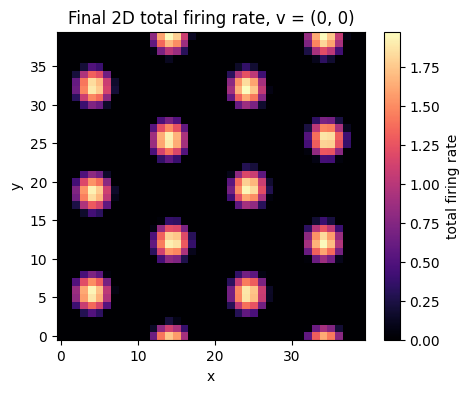

In [7]:
params_2d = Grid2DParams()
model_2d = FourPopulationGridIntegrator(params_2d)

velocity_zero = np.zeros((400, 2))  # columns are vx, vy

result_2d_zero = model_2d.simulate(
    velocity_zero,
    seed=1,
    store_history=True,
)

r_total_final = result_2d_zero["final_rate_total"]

plt.figure(figsize=(5, 4))
plt.imshow(r_total_final, origin="lower", cmap="magma")
plt.colorbar(label="total firing rate")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Final 2D total firing rate, v = (0, 0)")
plt.show()

With periodic boundary conditions and zero velocity input, all four populations receive the same external drive. Therefore, there is no directional bias in the network.

After about 400 ms, the initially random activity stabilizes into a periodic pattern of localized activity bumps. The final heatmap of $r_{\mathrm{total}}(x,y)$ shows multiple bumps arranged across the 2D neural sheet, so yes, the network produces a grid-like activity pattern. The pattern is not perfectly hexagonal, but it is clearly periodic and stable.

## Exercise 2.3 — 2D Velocity Integration

To test whether the 2D grid pattern acts as a continuous velocity integrator, we apply constant velocity inputs in different directions. Each simulation first runs for 300 ms with zero velocity so that the grid pattern can stabilize. Then a constant velocity is applied for another 300 ms.

We test three velocity directions: horizontal, vertical, and diagonal. If the model works as a 2D path integrator, the entire grid pattern should translate coherently in the direction determined by the input velocity, while approximately preserving its spatial structure.

In [8]:
def constant_velocity_2d_protocol(vx, vy, warmup_steps=300, moving_steps=300):
    """
    Create a 2D velocity trace.
    First warmup_steps have velocity (0, 0).
    Then moving_steps have constant velocity (vx, vy).
    """
    velocity = np.zeros((warmup_steps + moving_steps, 2))
    velocity[warmup_steps:, 0] = vx
    velocity[warmup_steps:, 1] = vy
    return velocity

In [9]:
velocity_cases = {
    "horizontal": (1.0, 0.0),
    "vertical": (0.0, 1.0),
    "diagonal": (1.0, 1.0),
}

results_2d_velocity = {}

for name, (vx, vy) in velocity_cases.items():
    velocity = constant_velocity_2d_protocol(vx, vy)

    result = model_2d.simulate(
        velocity,
        seed=1,
        store_history=True,
    )

    results_2d_velocity[name] = result

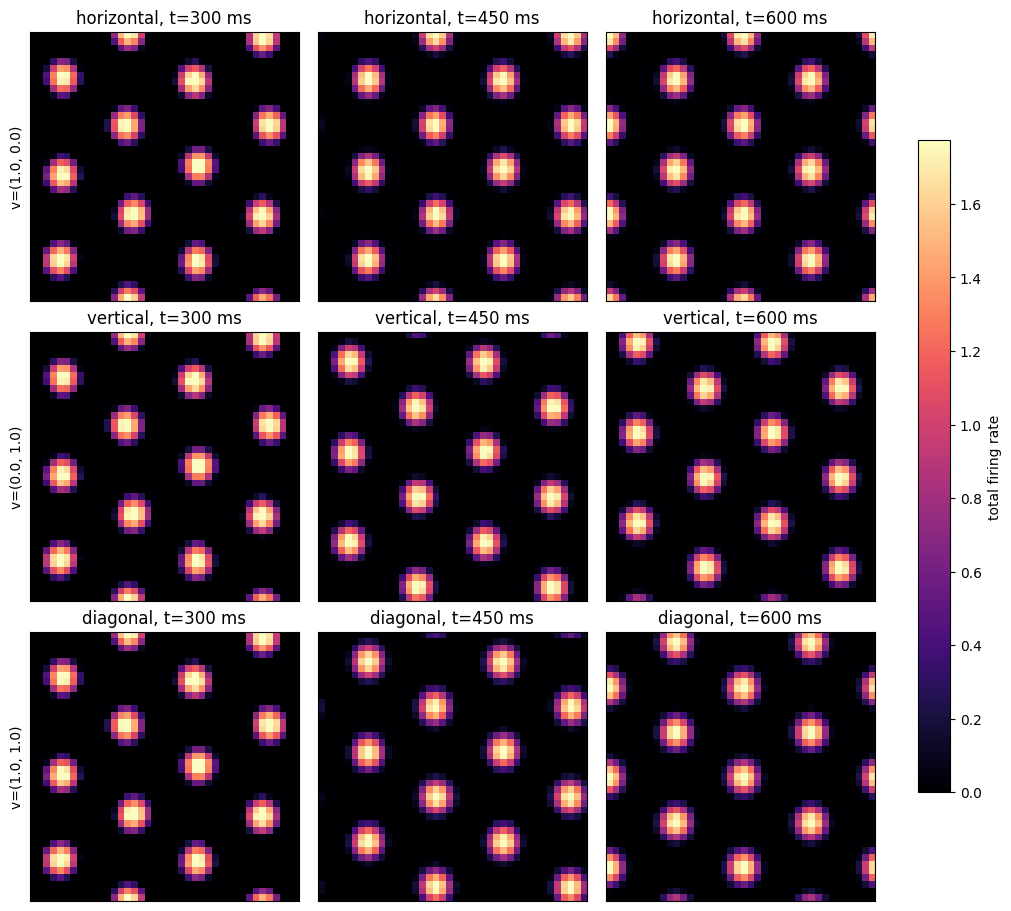

In [10]:
time_points = [299, 449, 599]

fig, axes = plt.subplots(
    nrows=len(velocity_cases),
    ncols=len(time_points),
    figsize=(10, 9),
    constrained_layout=True,
)

for row, (name, result) in enumerate(results_2d_velocity.items()):
    activity = result["rate_total"]

    vmax = np.percentile(activity, 99)

    for col, t in enumerate(time_points):
        ax = axes[row, col]
        im = ax.imshow(
            activity[t],
            origin="lower",
            cmap="magma",
            vmin=0,
            vmax=vmax,
        )

        vx, vy = velocity_cases[name]
        ax.set_title(f"{name}, t={t+1} ms")
        ax.set_xticks([])
        ax.set_yticks([])

        if col == 0:
            ax.set_ylabel(f"v=({vx}, {vy})")

fig.colorbar(im, ax=axes, shrink=0.75, label="total firing rate")
plt.show()

For each velocity direction, the network first forms a stable grid-like pattern during the initial 300 ms zero-velocity period. After the velocity input is turned on, the whole pattern translates while approximately preserving its structure.

For the horizontal velocity input, the pattern mainly shifts along the x-axis. For the vertical velocity input, the pattern mainly shifts along the y-axis. For the diagonal velocity input, the pattern shifts along both axes. This shows that the 2D grid pattern behaves like a continuous attractor: the activity pattern is not recreated from scratch, but moves coherently according to the velocity input.

## Exercise 2.4 — Changing Velocity Input

In this bonus exercise, we apply a time-dependent 2D velocity signal. The velocity direction changes every 100 ms, while the speed is sampled uniformly between 1 and 2. The goal is to test whether the 2D grid pattern can continuously track changing velocity inputs.

To estimate the velocity from the neural activity, we compare the grid pattern between two nearby time windows and estimate the spatial displacement of the pattern. Dividing this displacement by the time interval gives an estimated grid velocity. If the network acts as a good path integrator, the estimated velocity should qualitatively follow the input velocity.

In [11]:
from scipy.ndimage import gaussian_filter1d

def changing_velocity_2d_protocol(
    seed=0,
    warmup_steps=300,
    n_segments=10,
    segment_steps=100,
    speed_min=1.0,
    speed_max=2.0,
    smooth_sigma=5.0,
):
    """
    Generate a 2D velocity trace.
    
    First warmup_steps have velocity (0, 0).
    Then velocity direction changes every segment_steps.
    Speed is sampled uniformly from [speed_min, speed_max].
    """
    rng = np.random.default_rng(seed)

    total_moving_steps = n_segments * segment_steps
    total_steps = warmup_steps + total_moving_steps

    velocity = np.zeros((total_steps, 2))

    segment_velocities = []

    for i in range(n_segments):
        theta = rng.uniform(0, 2 * np.pi)
        speed = rng.uniform(speed_min, speed_max)

        vx = speed * np.cos(theta)
        vy = speed * np.sin(theta)

        start = warmup_steps + i * segment_steps
        end = start + segment_steps

        velocity[start:end, 0] = vx
        velocity[start:end, 1] = vy

        segment_velocities.append((vx, vy))

    segment_velocities = np.array(segment_velocities)

    # optional smoothing at transition points
    if smooth_sigma is not None and smooth_sigma > 0:
        velocity[:, 0] = gaussian_filter1d(velocity[:, 0], sigma=smooth_sigma)
        velocity[:, 1] = gaussian_filter1d(velocity[:, 1], sigma=smooth_sigma)

        # keep warmup exactly zero
        velocity[:warmup_steps] = 0.0

    segment_starts = warmup_steps + np.arange(n_segments) * segment_steps

    return velocity, segment_velocities, segment_starts

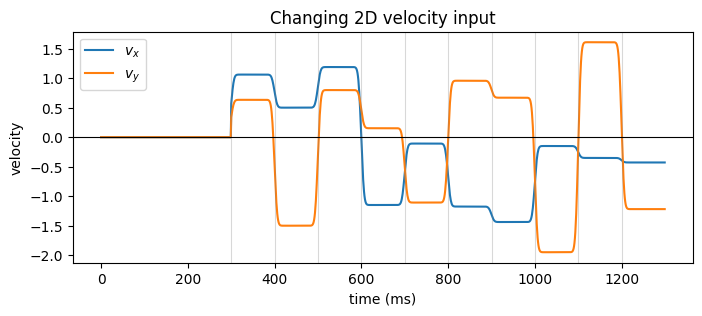

In [12]:
velocity_changing, segment_velocities, segment_starts = changing_velocity_2d_protocol(
    seed=3,
    warmup_steps=300,
    n_segments=10,
    segment_steps=100,
    speed_min=1.0,
    speed_max=2.0,
    smooth_sigma=5.0,
)

time = np.arange(len(velocity_changing))

plt.figure(figsize=(8, 3))
plt.plot(time, velocity_changing[:, 0], label=r"$v_x$")
plt.plot(time, velocity_changing[:, 1], label=r"$v_y$")
for start in segment_starts:
    plt.axvline(start, color="gray", alpha=0.3, linewidth=0.8)
plt.axhline(0, color="black", linewidth=0.8)
plt.xlabel("time (ms)")
plt.ylabel("velocity")
plt.title("Changing 2D velocity input")
plt.legend()
plt.show()

In [13]:
result_changing = model_2d.simulate(
    velocity_changing,
    seed=1,
    store_history=True,
)

activity_changing = result_changing["rate_total"]

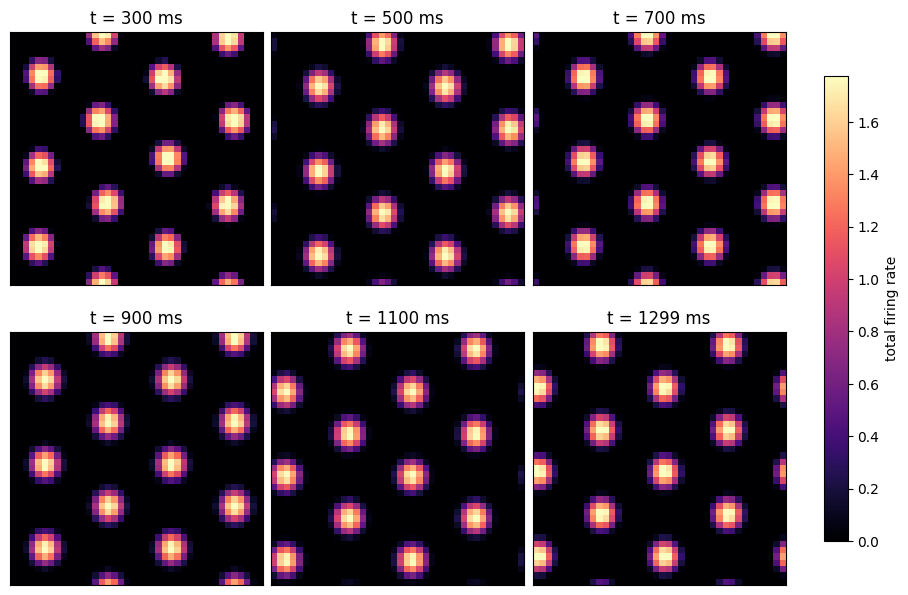

In [14]:
snapshot_times = [300, 500, 700, 900, 1100, 1299]

fig, axes = plt.subplots(2, 3, figsize=(9, 6), constrained_layout=True)

vmax = np.percentile(activity_changing, 99)

for ax, t in zip(axes.ravel(), snapshot_times):
    ax.imshow(
        activity_changing[t],
        origin="lower",
        cmap="magma",
        vmin=0,
        vmax=vmax,
    )
    ax.set_title(f"t = {t} ms")
    ax.set_xticks([])
    ax.set_yticks([])

fig.colorbar(ax.images[0], ax=axes, shrink=0.8, label="total firing rate")
plt.show()

In [15]:
def estimate_shift_phase_correlation(frame_a, frame_b):
    """
    Estimate circular shift from frame_a to frame_b using phase correlation.
    
    Returns
    -------
    dx, dy : float
        Estimated shift in x and y pixel units.
    """
    a = frame_a - frame_a.mean()
    b = frame_b - frame_b.mean()

    Fa = np.fft.fft2(a)
    Fb = np.fft.fft2(b)

    cross_power = Fb * np.conj(Fa)
    cross_power /= np.abs(cross_power) + 1e-12

    corr = np.fft.ifft2(cross_power).real

    peak_y, peak_x = np.unravel_index(np.argmax(corr), corr.shape)

    m_y, m_x = corr.shape

    # convert circular shift to signed shift
    if peak_x > m_x // 2:
        peak_x -= m_x
    if peak_y > m_y // 2:
        peak_y -= m_y

    dx = peak_x
    dy = peak_y

    return dx, dy

In [16]:
def estimate_segment_velocities_2d(
    activity,
    segment_starts,
    segment_steps=100,
    dt_ms=1.0,
    window=10,
):
    """
    Estimate grid velocity for each segment using phase correlation.
    """
    estimated = []

    for start in segment_starts:
        start = int(start)
        end = int(start + segment_steps)

        # average over small windows to reduce noise/transient effects
        frame_a = activity[start:start + window].mean(axis=0)
        frame_b = activity[end - window:end].mean(axis=0)

        dx, dy = estimate_shift_phase_correlation(frame_a, frame_b)

        duration_ms = (segment_steps - window) * dt_ms

        vx_hat = dx / duration_ms
        vy_hat = dy / duration_ms

        estimated.append((vx_hat, vy_hat))

    return np.array(estimated)

In [17]:
estimated_velocities = estimate_segment_velocities_2d(
    activity_changing,
    segment_starts=segment_starts,
    segment_steps=100,
    dt_ms=params_2d.dt_ms,
    window=10,
)

In [18]:
true_segment_velocities = []

for start in segment_starts:
    start = int(start)
    end = int(start + 100)
    true_segment_velocities.append(velocity_changing[start:end].mean(axis=0))

true_segment_velocities = np.array(true_segment_velocities)

In [21]:
def rescale_to_match(true, estimated):
    """
    Rescale estimated signal to best match true signal in least-squares sense.
    This is only for comparing temporal trends, not absolute magnitude.
    """
    denom = np.sum(estimated**2)
    if denom < 1e-12:
        return estimated, 1.0
    scale = np.sum(true * estimated) / denom
    return estimated * scale, scale


estimated_scaled = np.zeros_like(estimated_velocities)

estimated_scaled[:, 0], scale_x = rescale_to_match(
    true_segment_velocities[:, 0],
    estimated_velocities[:, 0],
)

estimated_scaled[:, 1], scale_y = rescale_to_match(
    true_segment_velocities[:, 1],
    estimated_velocities[:, 1],
)

print("scale_x:", scale_x)
print("scale_y:", scale_y)

scale_x: 51.42958741868648
scale_y: 54.70787436983667


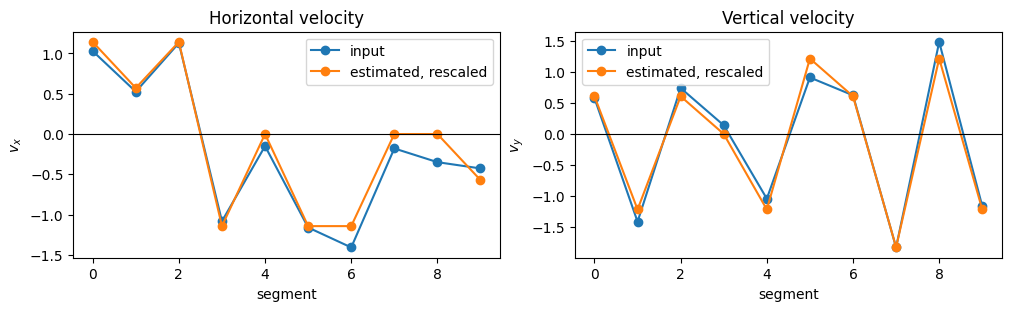

In [22]:
segments = np.arange(len(segment_starts))

fig, axes = plt.subplots(1, 2, figsize=(10, 3), constrained_layout=True)

axes[0].plot(segments, true_segment_velocities[:, 0], "o-", label="input")
axes[0].plot(segments, estimated_scaled[:, 0], "o-", label="estimated, rescaled")
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_xlabel("segment")
axes[0].set_ylabel(r"$v_x$")
axes[0].set_title("Horizontal velocity")
axes[0].legend()

axes[1].plot(segments, true_segment_velocities[:, 1], "o-", label="input")
axes[1].plot(segments, estimated_scaled[:, 1], "o-", label="estimated, rescaled")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_xlabel("segment")
axes[1].set_ylabel(r"$v_y$")
axes[1].set_title("Vertical velocity")
axes[1].legend()

plt.show()

The estimated velocity tracks the input velocity quite well after rescaling. For both $v_x$ and $v_y$, the estimated components recover most of the sign changes and temporal fluctuations of the input velocity. This suggests that the drifting grid pattern contains enough information to approximately reconstruct the changing velocity signal.

However, the match is not perfect, especially for a few $v_x$ segments, likely because the input velocity and neural-sheet displacement are in different units and because the periodic grid pattern can make displacement estimation ambiguous. Overall, however, the model qualitatively tracks the changing velocity input well.